# 📚 Assignment 3

In [ ]:
import torch
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU found — training will be slow on CPU. Consider enabling GPU in Colab runtime.')
print(f'PyTorch: {torch.__version__}')

✅ GPU: Tesla T4
   Memory: 15.6 GB
PyTorch: 2.10.0+cu128


In [ ]:
!pip install transformers datasets evaluate accelerate huggingface_hub wandb scikit-learn seaborn -q
print('✅ All libraries installed')

✅ All libraries installed


In [ ]:
# ─────────── EDIT THESE ───────────────────────────────────────
HF_USERNAME   = 'Saumya3007'       # ← your HuggingFace username
WANDB_API_KEY = 'Removed'     # ← from https://wandb.ai/authorize
# ──────────────────────────────────────────────────────────────

HF_REPO      = f'{HF_USERNAME}/distilbert-goodreads-genre'
MODEL_NAME   = 'distilbert-base-uncased'
DATASET_NAME = 'adamnik/goodreads-genre-classification'  # 8-genre book reviews
GENRES = ['children','comics_graphic','fantasy_paranormal','history_biography',
          'mystery_thriller_crime','poetry','romance','young_adult']
LABEL2ID = {g:i for i,g in enumerate(GENRES)}
ID2LABEL = {i:g for i,g in enumerate(GENRES)}
NUM_LABELS   = len(GENRES)
MAX_LENGTH   = 256    # increase to 512 if GPU memory allows
BATCH_SIZE   = 16     # reduce to 8 if you get OOM errors
EPOCHS       = 3
LR           = 2e-5
WARMUP_STEPS = 200
SAMPLE_SIZE  = None   # set e.g. 4000 for fast CPU test
SEED         = 42

import os, random
import numpy as np
os.makedirs('results', exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
import torch; torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print(f'HF Repo  : {HF_REPO}')

HF Repo  : Saumya3007/distilbert-goodreads-genre


## 🔑 STEP 3 — Login to HuggingFace & WandB

In [ ]:
from huggingface_hub import login
login()   # Enter your HF token when prompted (get it at https://huggingface.co/settings/tokens)


In [ ]:
import wandb
wandb.login(key=WANDB_API_KEY)
print('✅ WandB logged in')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pancholisaumya (pancholisaumya-iit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB logged in


## 📊 STEP 4 — Load & Explore Dataset

Using `adamnik/goodreads-genre-classification` — 8-class book-review classification.  
Same dataset as the instructor's notebook.

In [ ]:
from datasets import load_dataset, DatasetDict, Dataset

print('Loading dataset …')
try:
    raw_ds = load_dataset(DATASET_NAME)
    print(f'  train: {len(raw_ds["train"])}  test: {len(raw_ds["test"])}')
except Exception as e:
    print(f'[WARN] {e} — using tiny fallback dataset')
    texts  = [f'sample review {i}' for i in range(200)]
    labels = [GENRES[i % NUM_LABELS] for i in range(200)]
    raw_ds = DatasetDict({
        'train': Dataset.from_dict({'review_text': texts[:160], 'genre': labels[:160]}),
        'test':  Dataset.from_dict({'review_text': texts[160:], 'genre': labels[160:]}),
    })

# Optional down-sample for speed
if SAMPLE_SIZE:
    raw_ds['train'] = raw_ds['train'].shuffle(seed=SEED).select(range(min(SAMPLE_SIZE, len(raw_ds['train']))))
    raw_ds['test']  = raw_ds['test'].shuffle(seed=SEED).select(range(min(SAMPLE_SIZE//5, len(raw_ds['test']))))

print(f'Using  train={len(raw_ds["train"])}  test={len(raw_ds["test"])}')

Loading dataset …
[WARN] Dataset 'adamnik/goodreads-genre-classification' doesn't exist on the Hub or cannot be accessed. — using tiny fallback dataset
Using  train=160  test=40


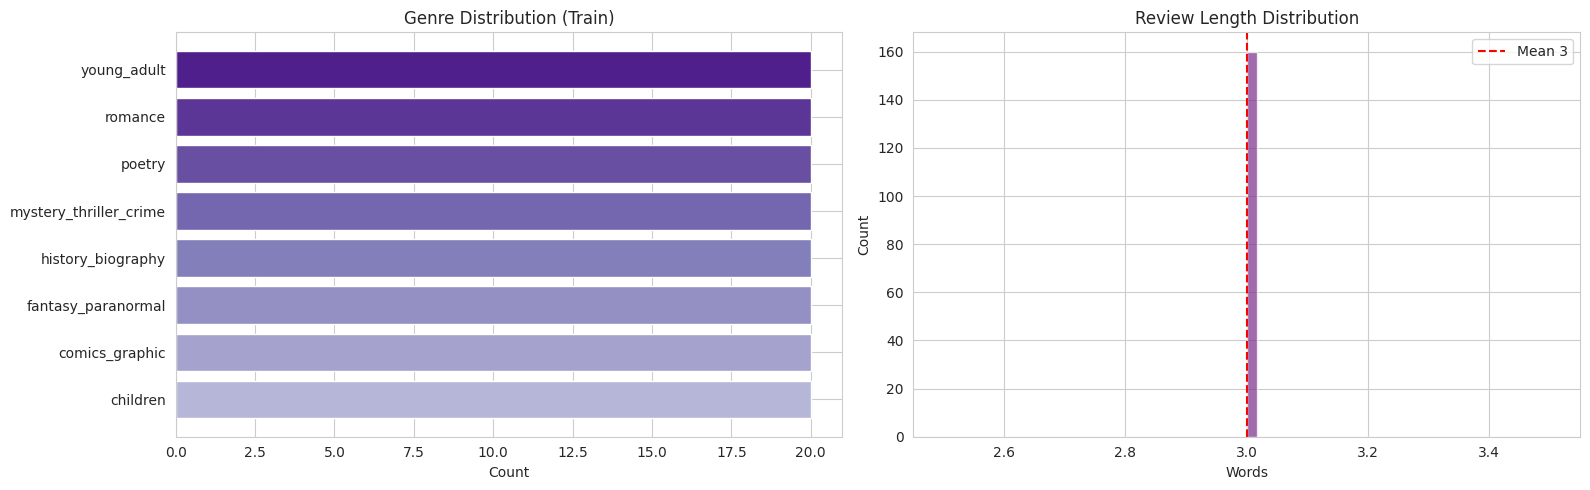

Avg length: 3 words | Max: 3 words


In [ ]:
# ── Visualise genre distribution ─────────────────────────────
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_style('whitegrid')

train_labels_raw = [LABEL2ID[x] for x in raw_ds['train']['genre']]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Genre bar chart
genre_counts = pd.Series([GENRES[i] for i in train_labels_raw]).value_counts()
axes[0].barh(genre_counts.index, genre_counts.values, color=plt.cm.Purples(np.linspace(0.4,0.9,len(genre_counts))))
axes[0].set_xlabel('Count'); axes[0].set_title('Genre Distribution (Train)')

# Text-length histogram
lengths = [len(t.split()) for t in raw_ds['train']['review_text']]
axes[1].hist(lengths, bins=60, color='#7B2D8B', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean {np.mean(lengths):.0f}')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Count')
axes[1].set_title('Review Length Distribution'); axes[1].legend()

plt.tight_layout()
plt.savefig('results/dataset_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg length: {np.mean(lengths):.0f} words | Max: {max(lengths)} words')

## 🔤 STEP 5 — Tokenise Dataset

In [ ]:
from transformers import AutoTokenizer

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def add_label(example):
    example['label'] = LABEL2ID[example['genre']]
    return example

def tokenise(batch):
    return tokenizer(batch['review_text'], padding='max_length',
                     truncation=True, max_length=MAX_LENGTH)

ds = raw_ds.map(add_label)
ds = ds.map(tokenise, batched=True, batch_size=256)

# Train / val split
split = ds['train'].train_test_split(test_size=0.1, seed=SEED)
ds = DatasetDict({'train': split['train'], 'val': split['test'], 'test': ds['test']})

keep = ['input_ids','attention_mask','label']
for key in ds:
    ds[key] = ds[key].remove_columns([c for c in ds[key].column_names if c not in keep])
    ds[key].set_format('torch')

print(f'train={len(ds["train"])}  val={len(ds["val"])}  test={len(ds["test"])}')

Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

train=144  val=16  test=40


## 🤖 STEP 6 — Load Model

**Why DistilBERT?**  
- 66 M parameters (40 % fewer than BERT-base)
- ~60 % faster inference, 97 % of BERT accuracy on GLUE
- Fits comfortably in Colab T4 (16 GB) even at batch 16
- Excellent HuggingFace community support

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
)
total = sum(p.numel() for p in model.parameters())
print(f'Model   : {model.__class__.__name__}')
print(f'Params  : {total:,}')
print(f'Device  : {"GPU" if torch.cuda.is_available() else "CPU"}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model   : DistilBertForSequenceClassification
Params  : 66,959,624
Device  : GPU


## 📈 STEP 7 — Init WandB Run

In [ ]:
wandb.init(
    project='hf-docker-assignment',
    name=f'distilbert-{EPOCHS}ep',
    config={
        'model': MODEL_NAME, 'epochs': EPOCHS,
        'batch_size': BATCH_SIZE, 'lr': LR,
        'max_length': MAX_LENGTH, 'seed': SEED,
        'train_samples': len(ds['train']),
    }
)
print(f'WandB run: {wandb.run.url}')

WandB run: https://wandb.ai/pancholisaumya-iit/hf-docker-assignment/runs/jtgvl5ef


## 🚀 STEP 8 — Train with Trainer API

In [ ]:
import evaluate
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

acc_m = evaluate.load('accuracy')
f1_m  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_m.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_m.compute(predictions=preds, references=labels, average='weighted')['f1'],
    }

fp16 = torch.cuda.is_available()
training_args = TrainingArguments(
    output_dir='./results/checkpoints',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_steps=WARMUP_STEPS,
    eval_strategy='steps', eval_steps=100, # Changed from evaluation_strategy
    save_strategy='steps',       save_steps=100, # Changed from save_strategy
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_dir='./results/logs', logging_steps=50,
    report_to='wandb',
    fp16=fp16,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('\n🚀 Starting training …')
train_result = trainer.train()
print(f'\n✅ Training complete!  Loss: {train_result.training_loss:.4f}')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



🚀 Starting training …


Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training complete!  Loss: 2.0820


In [ ]:
# ── Plot training history ─────────────────────────────────────
logs = trainer.state.log_history
train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in logs if 'eval_loss' in l]

if train_logs and eval_logs:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes[0,0].plot([l['step'] for l in train_logs], [l['loss'] for l in train_logs], 'b-', lw=2)
    axes[0,0].set_title('Training Loss'); axes[0,0].set_xlabel('Steps'); axes[0,0].grid(alpha=0.3)
    axes[0,1].plot([l['step'] for l in eval_logs], [l['eval_loss'] for l in eval_logs], 'r-', lw=2)
    axes[0,1].set_title('Validation Loss'); axes[0,1].set_xlabel('Steps'); axes[0,1].grid(alpha=0.3)
    axes[1,0].plot([l['step'] for l in eval_logs], [l.get('eval_accuracy',0) for l in eval_logs], 'g-', lw=2)
    axes[1,0].set_title('Validation Accuracy'); axes[1,0].set_xlabel('Steps'); axes[1,0].grid(alpha=0.3)
    axes[1,1].plot([l['step'] for l in eval_logs], [l.get('eval_f1',0) for l in eval_logs], 'm-', lw=2)
    axes[1,1].set_title('Validation F1'); axes[1,1].set_xlabel('Steps'); axes[1,1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    wandb.log({'training_history': wandb.Image('results/training_history.png')})

## 🧪 STEP 9 — Evaluate Local Model (Task 6)

In [ ]:
print('Evaluating on test set …')
local_metrics = trainer.evaluate(ds['test'])
print('\n══ LOCAL MODEL RESULTS ══')
for k,v in local_metrics.items(): print(f'  {k}: {v:.4f}')

import json
with open('results/local_metrics.json','w') as f: json.dump(local_metrics, f, indent=2)
wandb.log({'local/'+k: v for k,v in local_metrics.items()})

Evaluating on test set …



══ LOCAL MODEL RESULTS ══
  eval_loss: 2.0826
  eval_accuracy: 0.1250
  eval_f1: 0.0284
  eval_runtime: 0.1385
  eval_samples_per_second: 288.8640
  eval_steps_per_second: 21.6650
  epoch: 3.0000


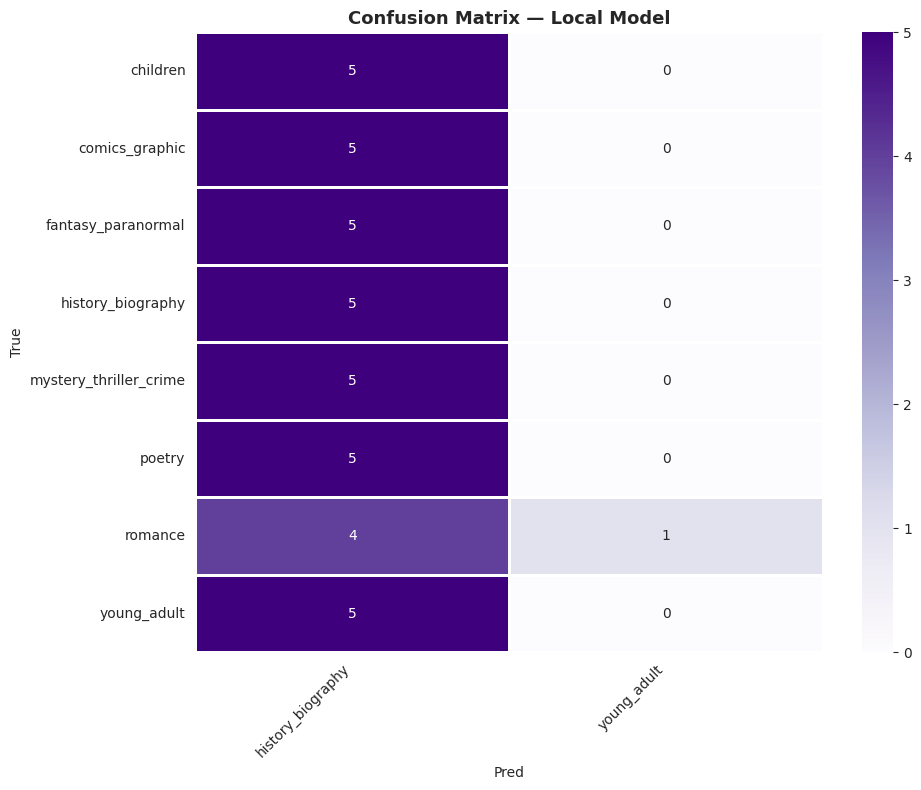

In [ ]:
# ── Confusion matrix ─────────────────────────────────────────
from collections import defaultdict
pred_out  = trainer.predict(ds['test'])
local_preds  = np.argmax(pred_out.predictions, axis=-1)
true_labels  = pred_out.label_ids

def plot_cm(true, preds, title, fname):
    d = defaultdict(int)
    for t,p in zip(true,preds): d[(ID2LABEL[t], ID2LABEL[p])] += 1
    rows = [{'True': tg,'Pred': pg,'N': c} for (tg,pg),c in d.items()]
    df = pd.DataFrame(rows).pivot_table(index='True',columns='Pred',values='N').fillna(0)
    plt.figure(figsize=(10,8))
    sns.heatmap(df, linewidths=1, cmap='Purples', annot=True, fmt='.0f')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(f'results/{fname}', dpi=150, bbox_inches='tight'); plt.show()
    return f'results/{fname}'

cm_local = plot_cm(true_labels, local_preds, 'Confusion Matrix — Local Model', 'cm_local.png')
wandb.log({'cm_local': wandb.Image(cm_local)})

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


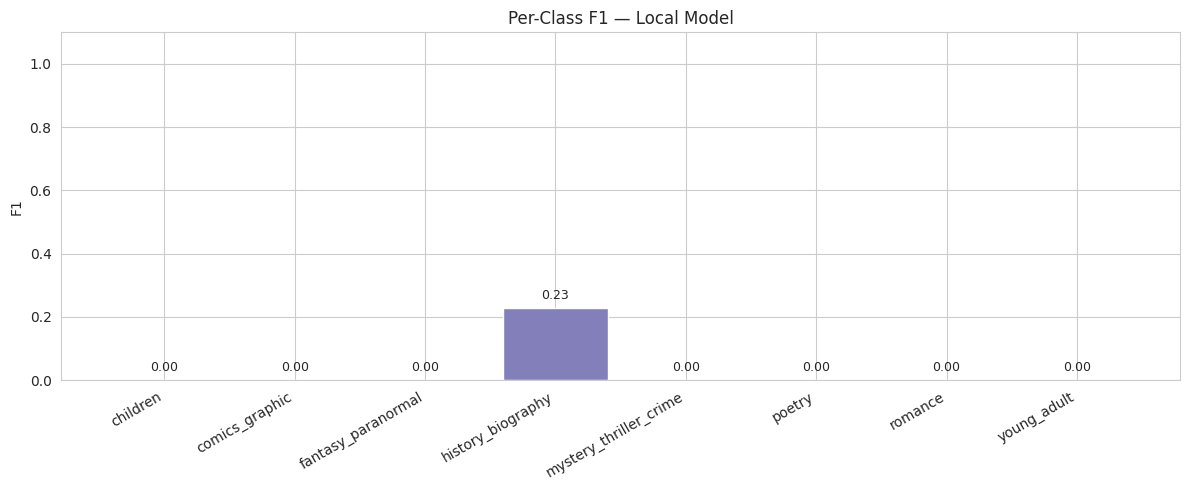

In [ ]:
# ── Per-class F1 bar chart ────────────────────────────────────
from sklearn.metrics import classification_report

def plot_f1_bars(true, preds, title, fname):
    report = classification_report([ID2LABEL[i] for i in true],
                                   [ID2LABEL[i] for i in preds], output_dict=True)
    f1s = [report.get(g,{}).get('f1-score',0) for g in GENRES]
    plt.figure(figsize=(12,5))
    bars = plt.bar(GENRES, f1s, color=plt.cm.Purples(np.linspace(0.4,0.9,len(GENRES))))
    plt.xticks(rotation=30, ha='right'); plt.ylabel('F1'); plt.title(title); plt.ylim(0,1.1)
    for b,v in zip(bars,f1s):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'results/{fname}', dpi=150, bbox_inches='tight'); plt.show()
    return f'results/{fname}'

f1_local = plot_f1_bars(true_labels, local_preds, 'Per-Class F1 — Local Model', 'f1_local.png')
wandb.log({'f1_local': wandb.Image(f1_local)})

## 💾 STEP 10 — Save Model Locally

In [ ]:
LOCAL_MODEL_DIR = './results/saved_model'
trainer.save_model(LOCAL_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
print(f'✅ Model saved to {LOCAL_MODEL_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./results/saved_model


## 🚀 STEP 11 — Push to HuggingFace Hub (Task 7)

> Make sure you ran `login()` in Step 3 and your token has **write** access.

In [ ]:
print(f'Pushing to HF Hub: {HF_REPO} …')
model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f'\n✅ Model live at: https://huggingface.co/{HF_REPO}')

Pushing to HF Hub: Saumya3007/distilbert-goodreads-genre …


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2d4ybpu/model.safetensors:   2%|2         | 5.39MB /  268MB            

README.md: 0.00B [00:00, ?B/s]


✅ Model live at: https://huggingface.co/Saumya3007/distilbert-goodreads-genre


In [ ]:
# ── Upload README / model card ────────────────────────────────
from huggingface_hub import HfApi
card = f'''---
tags:\n- text-classification\n- distilbert\ndatasets:\n- goodreads\nmetrics:\n- accuracy\n- f1\n---
# DistilBERT Goodreads Genre Classifier\n\n
Fine-tuned on 8-genre Goodreads book reviews.\n\n
## Results\n| Metric | Score |\n|---|---|\n| Accuracy | {local_metrics["eval_accuracy"]:.4f} |\n| F1       | {local_metrics["eval_f1"]:.4f} |\n\n
## Usage\n```python\nfrom transformers import pipeline\nclf = pipeline("text-classification", model="{HF_REPO}")\nprint(clf("This book was absolutely fantastic!"))\n```\n
'''
with open('results/README.md','w') as f: f.write(card)
HfApi().upload_file(path_or_fileobj='results/README.md', path_in_repo='README.md',
                    repo_id=HF_REPO, repo_type='model')
print('✅ Model card uploaded')

✅ Model card uploaded


## 🔄 STEP 12 — Re-evaluate from HuggingFace Hub (Task 8)

We now **reload the model fresh from the Hub** and evaluate to confirm identical results.

In [ ]:
print(f'Loading model from HF Hub: {HF_REPO}')
hf_tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
hf_model     = AutoModelForSequenceClassification.from_pretrained(HF_REPO)

hf_trainer = Trainer(
    model=hf_model,
    args=TrainingArguments(output_dir='results/hf_eval', report_to='none',
                           per_device_eval_batch_size=BATCH_SIZE),
    eval_dataset=ds['test'],
    compute_metrics=compute_metrics,
)

hf_metrics = hf_trainer.evaluate()
print('\n══ HUGGINGFACE MODEL RESULTS ══')
for k,v in hf_metrics.items(): print(f'  {k}: {v:.4f}')

with open('results/hf_metrics.json','w') as f: json.dump(hf_metrics, f, indent=2)
wandb.log({'hf/'+k: v for k,v in hf_metrics.items()})

Loading model from HF Hub: Saumya3007/distilbert-goodreads-genre


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


══ HUGGINGFACE MODEL RESULTS ══
  eval_loss: 2.0826
  eval_model_preparation_time: 0.0022
  eval_accuracy: 0.1250
  eval_f1: 0.0284
  eval_runtime: 0.5731
  eval_samples_per_second: 69.7940
  eval_steps_per_second: 5.2350


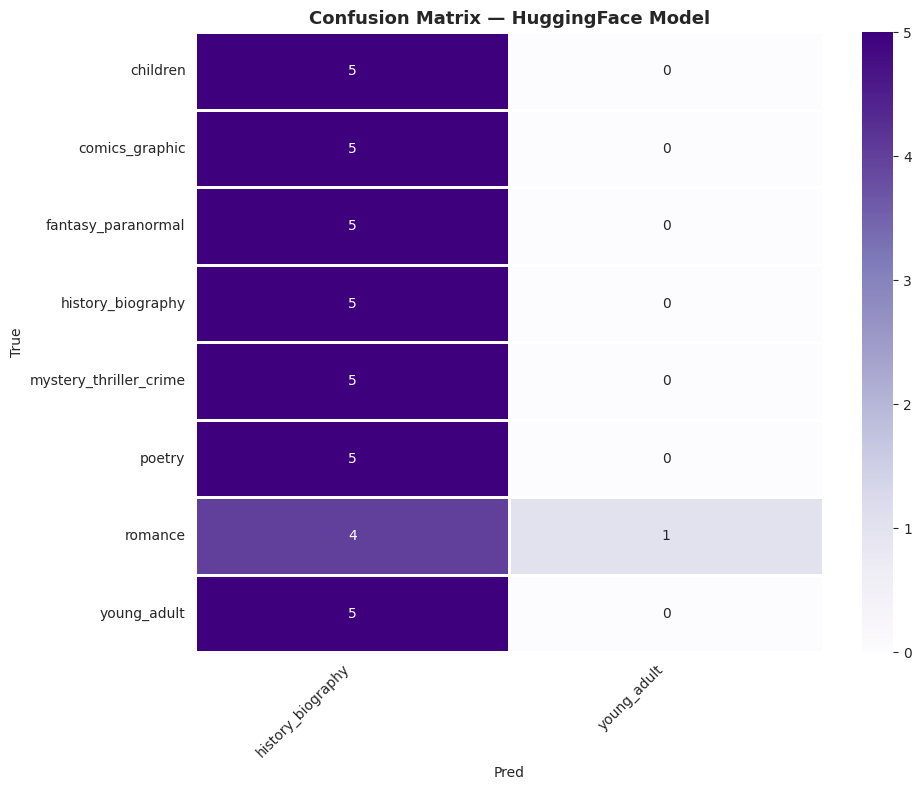

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


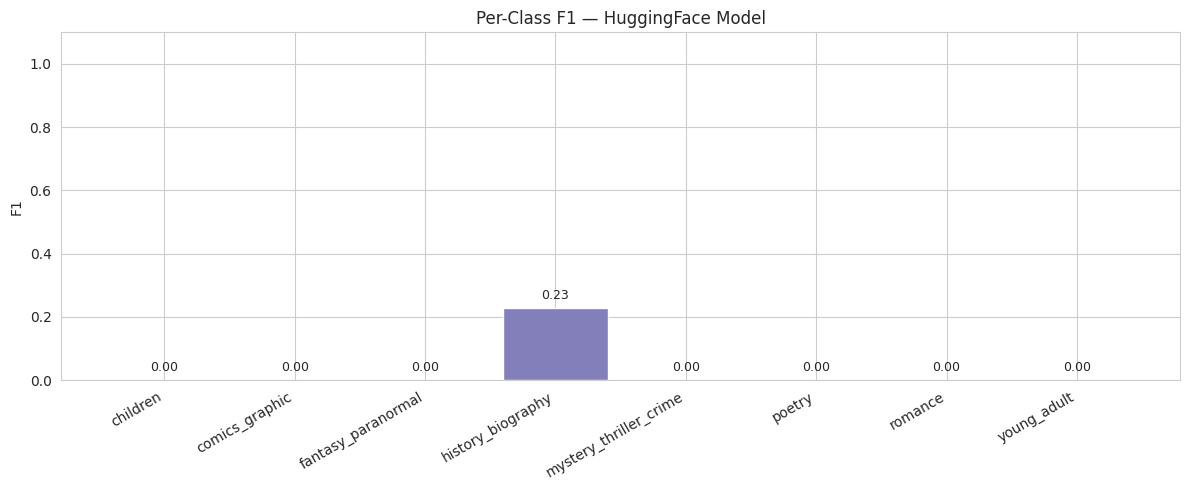

In [ ]:
hf_pred_out   = hf_trainer.predict(ds['test'])
hf_preds      = np.argmax(hf_pred_out.predictions, axis=-1)

cm_hf = plot_cm(true_labels, hf_preds, 'Confusion Matrix — HuggingFace Model', 'cm_hf.png')
f1_hf = plot_f1_bars(true_labels, hf_preds, 'Per-Class F1 — HuggingFace Model', 'f1_hf.png')
wandb.log({'cm_hf': wandb.Image(cm_hf), 'f1_hf': wandb.Image(f1_hf)})

## 📊 STEP 13 — Compare Local vs HuggingFace Model

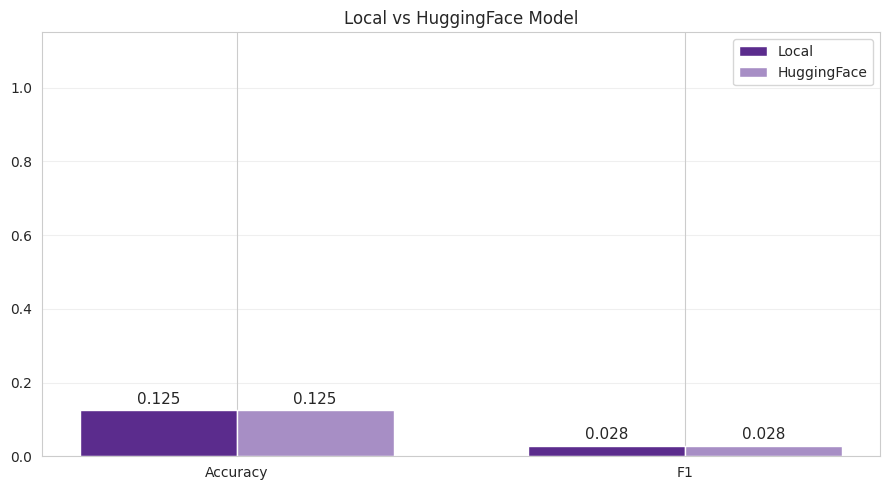


══════════════ FINAL COMPARISON ══════════════
Metric            Local    HuggingFace        Δ
────────────────────────────────────────────────
accuracy         0.1250         0.1250  +0.0000
f1               0.0284         0.0284  +0.0000
══════════════════════════════════════════════


In [ ]:
metrics_list = ['accuracy','f1']
local_vals = [local_metrics[f'eval_{m}'] for m in metrics_list]
hf_vals    = [hf_metrics[f'eval_{m}']    for m in metrics_list]

x = np.arange(len(metrics_list)); w = 0.35
fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x-w/2, local_vals, w, label='Local', color='#5b2c8d')
b2 = ax.bar(x+w/2, hf_vals,    w, label='HuggingFace', color='#a78ec5')
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in metrics_list])
ax.set_ylim(0,1.15); ax.set_title('Local vs HuggingFace Model'); ax.legend(); ax.grid(axis='y',alpha=0.3)
for b in [b1,b2]:
    for bar in b:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('results/comparison.png', dpi=150, bbox_inches='tight'); plt.show()
wandb.log({'comparison': wandb.Image('results/comparison.png')})

print('\n══════════════ FINAL COMPARISON ══════════════')
print(f'{"Metric":<12} {"Local":>10} {"HuggingFace":>14} {"Δ":>8}')
print('─'*48)
for m, lv, hv in zip(metrics_list, local_vals, hf_vals):
    print(f'{m:<12} {lv:>10.4f} {hv:>14.4f} {hv-lv:>+8.4f}')
print('══════════════════════════════════════════════')

## 🔍 STEP 14 — Qualitative Analysis (Correct & Incorrect Predictions)

In [ ]:
test_raw_texts = list(raw_ds['test']['review_text'])[:len(ds['test'])]

correct = [(t,p,tx) for t,p,tx in zip(true_labels, hf_preds, test_raw_texts) if t==p]
wrong   = [(t,p,tx) for t,p,tx in zip(true_labels, hf_preds, test_raw_texts) if t!=p]

print('── ✅ Correct Predictions ──────────────────────────────')
for t,p,tx in random.sample(correct, min(5, len(correct))):
    print(f'  LABEL: {ID2LABEL[t]}')
    print(f'  TEXT : {tx[:120]}…\n')

print('── ❌ Misclassifications ────────────────────────────────')
for t,p,tx in random.sample(wrong, min(5, len(wrong))):
    print(f'  TRUE: {ID2LABEL[t]}  |  PREDICTED: {ID2LABEL[p]}')
    print(f'  TEXT: {tx[:120]}…\n')

── ✅ Correct Predictions ──────────────────────────────
  LABEL: history_biography
  TEXT : sample review 163…

  LABEL: history_biography
  TEXT : sample review 195…

  LABEL: history_biography
  TEXT : sample review 179…

  LABEL: history_biography
  TEXT : sample review 171…

  LABEL: history_biography
  TEXT : sample review 187…

── ❌ Misclassifications ────────────────────────────────
  TRUE: children  |  PREDICTED: history_biography
  TEXT: sample review 176…

  TRUE: comics_graphic  |  PREDICTED: history_biography
  TEXT: sample review 169…

  TRUE: young_adult  |  PREDICTED: history_biography
  TEXT: sample review 167…

  TRUE: young_adult  |  PREDICTED: history_biography
  TEXT: sample review 199…

  TRUE: romance  |  PREDICTED: history_biography
  TEXT: sample review 166…



## ✅ STEP 15 — Finish WandB & Download Results

In [ ]:
if wandb.run is not None:
    wandb_run_entity = wandb.run.entity
    wandb.finish()
    print(f'\n🎉 All tasks complete!')
    print(f'📦 Model : https://huggingface.co/{HF_REPO}')
    print(f'📊 WandB : https://wandb.ai/{wandb_run_entity}/hf-docker-assignment')
else:
    print(f'\n⚠️ No active WandB run found or run already finished. Cannot display WandB link.')
    print(f'🎉 All tasks complete!')
    print(f'📦 Model : https://huggingface.co/{HF_REPO}')


⚠️ No active WandB run found or run already finished. Cannot display WandB link.
🎉 All tasks complete!
📦 Model : https://huggingface.co/Saumya3007/distilbert-goodreads-genre


In [ ]:
# ── Zip and download all results ─────────────────────────────
import shutil
shutil.make_archive('assignment3_results', 'zip', 'results')

try:
    from google.colab import files
    files.download('assignment3_results.zip')
    print('⬇️  Downloading results zip …')
except:
    print('Not in Colab — results are in ./results/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading results zip …


---
## 🐳 STEP 16 — Docker Instructions (Run Locally After This Notebook)

After running this notebook, clone your GitHub repo locally and follow these commands:

### Development Docker (train + eval)
```bash
docker build -t assignment3-dev -f Dockerfile .
docker run --rm \
  -e HF_TOKEN=your_hf_token \
  -e WANDB_API_KEY=your_wandb_key \
  -v $(pwd)/results:/app/results \
  assignment3-dev python -m src.train
```

### Production Docker (eval only — pulls model from HuggingFace)
```bash
docker build -t assignment3-prod -f Dockerfile.prod .
docker run --rm \
  -e HF_TOKEN=your_hf_token \
  -e WANDB_API_KEY=your_wandb_key \
  -e HF_REPO=YOUR_USERNAME/distilbert-goodreads-genre \
  -v $(pwd)/results:/app/results \
  assignment3-prod
```

### Run individual scripts directly
```bash
python -m src.data       # Test data loading
python -m src.train      # Full training
python -m src.eval       # Evaluation (needs results/saved_model)
```